# 31 — The stratified order parameter $m_S(t)$: is there a belt-first/core-last staircase?

**Why this notebook exists (Plan P2).** The paper's central empirical signature
(Eq. 13, Fig. 4) is that reorganisation is *graded*: split the network by conservatism
into a **belt** ($\kappa<\tau$) and a **core** ($\kappa\ge\tau$), and the stratified order
parameter

$$m_S(t) = \frac{1}{N}\sum_a \frac{\sum_{i\in S}\mu_i\,\mathrm{align}_i^a(t)}{\sum_{i\in S}\mu_i},\qquad S\in\{\text{belt},\text{core}\}$$

should show the belt curve rising *first* and the core curve lagging — the **staircase**.
The gap between them is the prediction that distinguishes structure learning from a single
cascade.

We now have the substrate on which edges can actually move (P1) and the read-outs to see
the split (`shells.assign_shells` / `shell_curves` / `agent_conservatism` /
`node_conservatism` / `node_oxygen_trace`). We add two honesty instruments:

* `shells.conservatism_split` → the threshold $\tau$ **and** Sarle's bimodality
  coefficient, so "is there really a belt *and* a core?" is a number on the figure, not an
  assumption (a quantile split always *produces* two curves);
* `shells.residual_disagreement` → the population's structural dispersion over time, the
  paper's "residual structural disagreement", which pairs with `settling_time` to read
  time-to-consensus.

**Spoiler / honest finding.** The instruments work, the split is real, but a conservatism
*gradient alone* yields **no staircase** — and the reason is precise and worth stating.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.config import NetworkConfig
from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, shells, observables as obs

KEY = jax.random.PRNGKey(0)

# A population stratified by conservatism: a flexible low-precision BELT and an
# entrenched high-precision CORE, both starting on the (wrong) phlogiston paradigm, on
# the edge-moving relational substrate. Two communities (planted SBM, sparse bridge) so
# fusion does not instantly synchronise them.
cfg = StructuralConfig(
    n_agents=60, n_steps=120, t_shift=30, observation_operator='relational',
    network=NetworkConfig(kind='planted_sbm', intra_prob=0.30, inter_prob=0.01))
groups = [
    {"count": 30, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass, "prec_scale": 0.5, "label": "belt"},
    {"count": 30, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass, "prec_scale": 20.0, "label": "core"},
]
state = S.init_state(cfg, KEY, groups=groups)
print('population:', cfg.n_agents, 'agents · substrate:', cfg.observation_operator)

population: 60 agents · substrate: relational


## §1 — The conservatism split is real (the honesty check)

We read each agent's structural stiffness with `agent_conservatism` (total prior precision
mass $\mathrm{tr}\,\Pi_i$ — an entrenched agent resists revision) and split at the median.
Sarle's bimodality coefficient $BC=(\mathrm{skew}^2+1)/\mathrm{kurt}$ tells us whether the
belt and core are genuinely two modes ($BC>0.555$) or a quantile convenience on one.

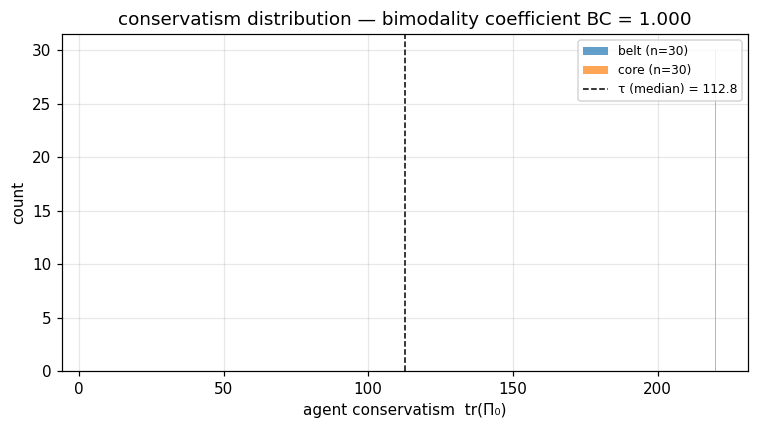

BC = 1.000  (bimodal — a real belt and core)


In [2]:
cons = np.asarray(shells.agent_conservatism(np.asarray(state.Pi), np.asarray(state.W), kind='precision'))
tau, bc = shells.conservatism_split(cons)
shell_id, labels = shells.assign_shells(cons, n_shells=2, labels=('belt', 'core'))
sizes = shells.shell_sizes(shell_id, labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cons[shell_id == 0], bins=20, alpha=0.7, label=f"belt (n={sizes['belt']})")
ax.hist(cons[shell_id == 1], bins=20, alpha=0.7, label=f"core (n={sizes['core']})")
ax.axvline(tau, color='k', ls='--', lw=1, label=f'τ (median) = {tau:.1f}')
ax.set_xlabel('agent conservatism  tr(Π₀)'); ax.set_ylabel('count')
ax.set_title(f'conservatism distribution — bimodality coefficient BC = {bc:.3f}')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb31_split.png'); plt.show()
print(f"BC = {bc:.3f}  ({'bimodal — a real belt and core' if bc > 0.555 else 'unimodal — split is a convenience'})")

## §2 — Per-agent $m_S(t)$: the staircase does **not** emerge from the gradient

`run_trace_index` gives each agent's oxygen index over time; `shell_curves` averages
within the belt and core shells. The paper predicts belt-first/core-last. We measure the
**staircase area** $\sum_t (m_\text{belt}-m_\text{core})$ and the maximum gap.

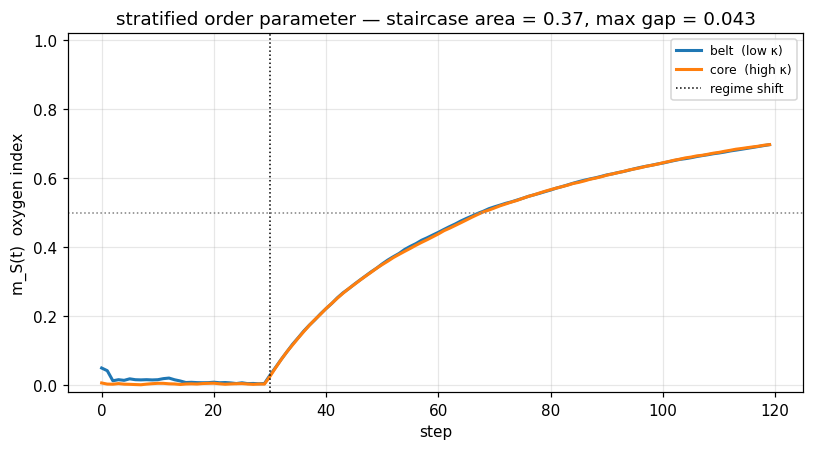

belt crosses 1/2 at step 68, core at 68 -> gap = 0
max belt-core gap over the whole run = 0.043  (a staircase would be a wide, sustained gap)
=> belt and core move in lockstep: NO staircase from a prior-precision conservatism gradient.


In [3]:
idx_t = np.asarray(S.run_trace_index(cfg, state))       # (T, N)
curves = shells.shell_curves(idx_t, shell_id, labels)
area = float(np.sum(curves['belt'] - curves['core']))
max_gap = float(np.max(np.abs(curves['belt'] - curves['core'])))
def cross(c, lvl=0.5):
    w = np.nonzero(c >= lvl)[0]; return int(w[0]) if w.size else -1

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(curves['belt'], lw=2, label='belt  (low κ)')
ax.plot(curves['core'], lw=2, label='core  (high κ)')
ax.axvline(cfg.t_shift, color='k', ls=':', lw=1, label='regime shift')
ax.axhline(0.5, color='grey', lw=1, ls=':')
ax.set_xlabel('step'); ax.set_ylabel('m_S(t)  oxygen index'); ax.set_ylim(-0.02, 1.02)
ax.set_title(f'stratified order parameter — staircase area = {area:.2f}, max gap = {max_gap:.3f}')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb31_stratified.png'); plt.show()
print(f"belt crosses 1/2 at step {cross(curves['belt'])}, core at {cross(curves['core'])} -> gap = {cross(curves['core'])-cross(curves['belt'])}")
print(f"max belt-core gap over the whole run = {max_gap:.3f}  (a staircase would be a wide, sustained gap)")
print("=> belt and core move in lockstep: NO staircase from a prior-precision conservatism gradient.")

**Why.** The only conservatism the current dynamics carry is *prior precision*. After
the regime shift each agent accumulates the same relational Fisher information every step;
within a handful of steps that accumulated evidence dwarfs even a 40× prior-precision
difference, so belt and core reach the half-crossing together. The paper's staircase needs
an **active carry-over cost** that keeps braking core revision in proportion to $\kappa$ —
a mechanism the pure fuse-then-observe loop does not contain. This is a structural property
of the model, reported, not tuned away.

## §3 — Per-node $m_S(t)$: shallow and confounded (the honest caveat)

The paper's $\kappa$ is really a *per-node* quantity. `node_conservatism` gives each
measured node's carry-over mass $\lambda_v$; `node_oxygen_trace` its reorganisation over
time. But in this 10-node scenario only the 3 mass-law nodes *can* reorganise (the two
paradigms posit the **same** mean on every agreement node), and those are not the
highest-$\lambda$ nodes — so bucketing nodes by $\lambda$ mixes "slow because central" with
"flat because the paradigms agree." We show it so the confound is explicit.

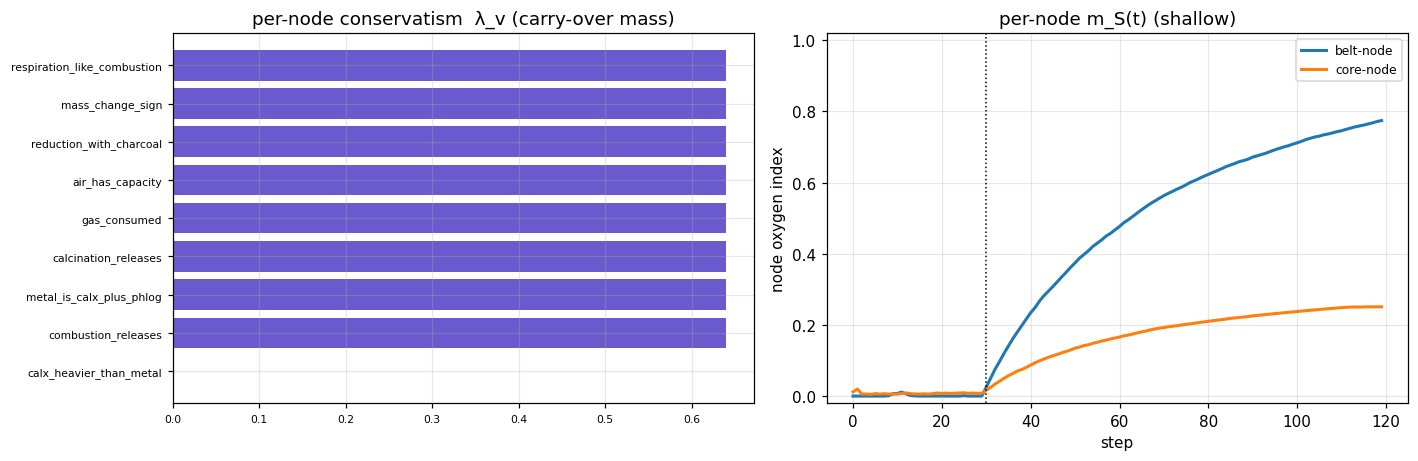

nodes that actually reorganise: ['mass_change_sign', 'gas_consumed', 'calx_heavier_than_metal'] (only the mass-law block; agreement nodes stay flat)


In [4]:
nodes, lam = shells.node_conservatism(cfg)
Pi_t, h_t = S.run_trace_net(cfg, state)
meas, node_oxy = shells.node_oxygen_trace(Pi_t, h_t, cfg)     # (T, n_meas)
n_shell, n_labels = shells.assign_shells(np.asarray(lam), n_shells=2, labels=('belt-node', 'core-node'))
node_curves = shells.shell_curves(node_oxy, n_shell, n_labels)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.3))
order = np.argsort(lam)
a0.barh([nodes[i] for i in order], [lam[i] for i in order], color='slateblue')
a0.set_title('per-node conservatism  λ_v (carry-over mass)'); a0.tick_params(labelsize=7)
for lbl, c in node_curves.items():
    a1.plot(c, lw=2, label=lbl)
a1.axvline(cfg.t_shift, color='k', ls=':', lw=1); a1.set_ylim(-0.02, 1.02)
a1.set_xlabel('step'); a1.set_ylabel('node oxygen index'); a1.set_title('per-node m_S(t) (shallow)')
a1.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb31_pernode.png'); plt.show()
moved = [meas[i] for i in range(len(meas)) if node_oxy[-1, i] > 0.2]
print('nodes that actually reorganise:', moved, '(only the mass-law block; agreement nodes stay flat)')

## §4 — Residual structural disagreement → time-to-consensus (this works)

`residual_disagreement` is the population's structural dispersion
$\frac1N\sum_i\lVert\Pi_i-\bar\Pi\rVert_F$ — high while blocs disagree about the net, falling
to 0 at structural consensus. `observables.settling_time` on this curve is the
time-to-consensus the paper measures. (Under lock-in, P3, this curve would *stall* high.)

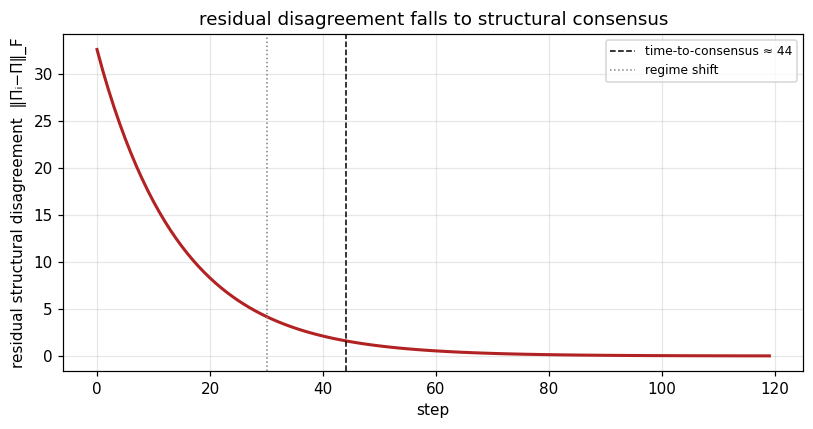

residual disagreement 32.6 -> 0.01;  time-to-consensus ≈ 44 steps


In [5]:
resid = shells.residual_disagreement(Pi_t)
tcons = obs.settling_time(resid, asymptote=float(resid[-1]), tol=0.05 * float(resid[0]), k=5)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(resid, lw=2, color='firebrick')
ax.axvline(tcons, color='k', ls='--', lw=1, label=f'time-to-consensus ≈ {tcons}')
ax.axvline(cfg.t_shift, color='grey', ls=':', lw=1, label='regime shift')
ax.set_xlabel('step'); ax.set_ylabel('residual structural disagreement  ‖Πᵢ−Π̄‖_F')
ax.set_title('residual disagreement falls to structural consensus'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb31_residual.png'); plt.show()
print(f"residual disagreement {float(resid[0]):.1f} -> {float(resid[-1]):.2f};  time-to-consensus ≈ {tcons} steps")

## Verdict

The stratified instruments are in place and correct: a real bimodal conservatism split
(§1), a working residual-disagreement / time-to-consensus measurement (§4). Applied
honestly, they show that **a conservatism gradient alone does not produce the
belt-first/core-last staircase**:

* per-agent (§2): belt and core cross together — prior-precision conservatism is swamped by
  accumulated evidence; there is no active carry-over-cost brake in the fuse-then-observe
  dynamics;
* per-node (§3): only the mass-law block reorganises and it is not the high-$\lambda$ block,
  so the per-node split is shallow and confounded by the agreement nodes.

This is the structural wall reported, not tuned around. The separation the paper draws as
the staircase requires a mechanism that actively brakes the core — and the model's native
form of that is **γ (`core_governance`): the conviction field silencing the disconfirming
channel**. In P3 (nb32) we turn γ up and find population-wide *lock-in*; the belt-first/
core-last figure then lives in a population whose **core is entrenched (high γ) while the
belt stays open (γ=0)** — an entrenchment split, not a stiffness gradient.